# Emotion Detection & Sentiment Analysis - ML Model Comparison
## Train 3 Models and Select the Best One
This notebook builds an emotion detection and sentiment analysis model using NLP and Machine Learning. We'll train three different algorithms (Logistic Regression, Naive Bayes, and SVM) and compare their performance to select the best model.

## 1. Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import re
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
print("NLTK data downloaded successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...


NLTK data downloaded successfully!


[nltk_data]   Package punkt is already up-to-date!


## 2. Load and Explore the Dataset

In [ ]:
# Load the emotion detection dataset
dataset = pd.read_csv('/content/drive/MyDrive/BTECH SEM 8/AIML-HONORS/combined_emotion.csv')

# Display basic information
print("Dataset Shape:", dataset.shape)
print("\nFirst 5 rows:")
print(dataset.head())
print("\nData Types:")
print(dataset.dtypes)
print("\nColumn Names:")
print(dataset.columns.tolist())

Dataset Shape: (422746, 2)

First 5 rows:
                                            sentence emotion
0      i just feel really helpless and heavy hearted    fear
1  ive enjoyed being able to slouch about relax a...     sad
2  i gave up my internship with the dmrg and am f...    fear
3                         i dont know i feel so lost     sad
4  i am a kindergarten teacher and i am thoroughl...    fear

Data Types:
sentence    object
emotion     object
dtype: object

Column Names:
['sentence', 'emotion']


In [ ]:
# Check for missing values
print("Missing Values:")
print(dataset.isnull().sum())
print("\nTotal Missing Values:", dataset.isnull().sum().sum())

Missing Values:
sentence    0
emotion     0
dtype: int64

Total Missing Values: 0



Emotion Distribution:
emotion
joy        143067
sad        121187
anger       59317
fear        49649
love        34554
suprise     14972
Name: count, dtype: int64


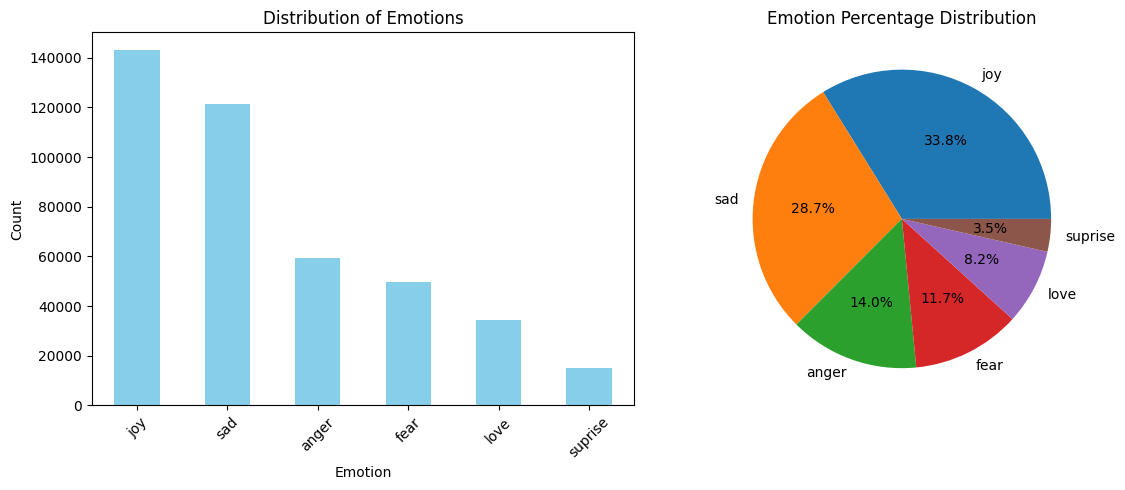

In [ ]:
# Distribution of emotions
print("\nEmotion Distribution:")
emotion_counts = dataset['emotion'].value_counts()
print(emotion_counts)

# Visualize the distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
emotion_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Emotions')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
emotion_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Emotion Percentage Distribution')
plt.ylabel('')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing and Text Cleaning

In [ ]:
# Initialize stemmer and stopwords
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Preprocess text by:
    1. Converting to lowercase
    2. Removing special characters and URLs
    3. Removing extra spaces
    4. Tokenizing
    5. Removing stopwords
    6. Stemming
    """
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove special characters and digits, keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    tokens = text.split()

    # Remove stopwords and apply stemming
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]

    return ' '.join(tokens)

# Apply preprocessing
print("Preprocessing text data... This may take a moment.")
dataset['cleaned_text'] = dataset['sentence'].apply(preprocess_text)

print("\nPreprocessing complete!")
print("\nOriginal vs Cleaned Text Examples:")
for i in range(min(5, len(dataset))):
    print(f"\n{i+1}. Original: {dataset['sentence'].iloc[i]}")
    print(f"   Cleaned:  {dataset['cleaned_text'].iloc[i]}")

Preprocessing text data... This may take a moment.

Preprocessing complete!

Original vs Cleaned Text Examples:

1. Original: i just feel really helpless and heavy hearted
   Cleaned:  feel realli helpless heavi heart

2. Original: ive enjoyed being able to slouch about relax and unwind and frankly needed it after those last few weeks around the end of uni and the expo i have lately started to find myself feeling a bit listless which is never really a good thing
   Cleaned:  ive enjoy abl slouch relax unwind frankli need last week around end uni expo late start find feel bit listless never realli good thing

3. Original: i gave up my internship with the dmrg and am feeling distraught
   Cleaned:  gave internship dmrg feel distraught

4. Original: i dont know i feel so lost
   Cleaned:  dont know feel lost

5. Original: i am a kindergarten teacher and i am thoroughly weary of my job after having taken the university entrance exam i suffered from anxiety for weeks as i did not want to ca

## 4. Feature Extraction with TF-IDF and Train-Test Split

In [ ]:
# Apply TF-IDF Vectorization
print("Applying TF-IDF Vectorization...")
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.8)

X = vectorizer.fit_transform(dataset['cleaned_text'])
y = dataset['emotion']

print(f"Feature Matrix Shape: {X.shape}")
print(f"Number of Features: {X.shape[1]}")
print(f"Number of Samples: {X.shape[0]}")

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining Set Size: {X_train.shape[0]}")
print(f"Testing Set Size: {X_test.shape[0]}")
print("\nTrain-Test split completed!")

Applying TF-IDF Vectorization...
Feature Matrix Shape: (422746, 5000)
Number of Features: 5000
Number of Samples: 422746

Training Set Size: 338196
Testing Set Size: 84550

Train-Test split completed!


## 5. Train Model 1: Logistic Regression

In [ ]:
print("Training Logistic Regression Model...")
model_lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
model_lr.fit(X_train, y_train)

# Predictions
y_pred_lr = model_lr.predict(X_test)

# Evaluation Metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

print(f"\nLogistic Regression Results:")
print(f"Accuracy:  {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1-Score:  {f1_lr:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

Training Logistic Regression Model...

Logistic Regression Results:
Accuracy:  0.8977
Precision: 0.8963
Recall:    0.8977
F1-Score:  0.8966

Confusion Matrix:
[[10645   333   296    54   523    12]
 [  321  8595   202    34   395   383]
 [  172   119 26777   992   373   181]
 [   56    33  1665  4978   165    14]
 [  522   336   412    97 22825    46]
 [   15   581   242    20    59  2077]]

Classification Report:
              precision    recall  f1-score   support

       anger       0.91      0.90      0.90     11863
        fear       0.86      0.87      0.86      9930
         joy       0.90      0.94      0.92     28614
        love       0.81      0.72      0.76      6911
         sad       0.94      0.94      0.94     24238
     suprise       0.77      0.69      0.73      2994

    accuracy                           0.90     84550
   macro avg       0.86      0.84      0.85     84550
weighted avg       0.90      0.90      0.90     84550



## 6. Train Model 2: Naive Bayes

In [ ]:
print("Training Multinomial Naive Bayes Model...")
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)

# Predictions
y_pred_nb = model_nb.predict(X_test)

# Evaluation Metrics
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average='weighted', zero_division=0)
recall_nb = recall_score(y_test, y_pred_nb, average='weighted', zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, average='weighted', zero_division=0)

print(f"\nNaive Bayes Results:")
print(f"Accuracy:  {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall:    {recall_nb:.4f}")
print(f"F1-Score:  {f1_nb:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, zero_division=0))

Training Multinomial Naive Bayes Model...

Naive Bayes Results:
Accuracy:  0.8582
Precision: 0.8637
Recall:    0.8582
F1-Score:  0.8498

Confusion Matrix:
[[ 9707   248   832    36  1038     2]
 [  327  7871   796    19   799   118]
 [   94    77 27482   333   587    41]
 [   53    27  2952  3447   429     3]
 [  218   181   892    34 22910     3]
 [   16   573   977    11   270  1147]]

Classification Report:
              precision    recall  f1-score   support

       anger       0.93      0.82      0.87     11863
        fear       0.88      0.79      0.83      9930
         joy       0.81      0.96      0.88     28614
        love       0.89      0.50      0.64      6911
         sad       0.88      0.95      0.91     24238
     suprise       0.87      0.38      0.53      2994

    accuracy                           0.86     84550
   macro avg       0.88      0.73      0.78     84550
weighted avg       0.86      0.86      0.85     84550



## 7. Train Model 3: Support Vector Machine (SVM)

In [ ]:
print("Training Fast Support Vector Machine (LinearSVC) Model...")
print("This will be much faster than SVC...")

from sklearn.svm import LinearSVC

# Train model
model_svm = LinearSVC(random_state=42)
model_svm.fit(X_train, y_train)

# Predictions
y_pred_svm = model_svm.predict(X_test)

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted', zero_division=0)
recall_svm = recall_score(y_test, y_pred_svm, average='weighted', zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, average='weighted', zero_division=0)

print(f"\nLinearSVC Results:")
print(f"Accuracy:  {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall:    {recall_svm:.4f}")
print(f"F1-Score:  {f1_svm:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, zero_division=0))

Training Support Vector Machine (SVM) Model...
This may take a moment...


## 8. Model Evaluation and Comparison

In [ ]:
# Create a comparison table
comparison_data = {
    'Model': ['Logistic Regression', 'Naive Bayes', 'Support Vector Machine (SVM)'],
    'Accuracy': [accuracy_lr, accuracy_nb, accuracy_svm],
    'Precision': [precision_lr, precision_nb, precision_svm],
    'Recall': [recall_lr, recall_nb, recall_svm],
    'F1-Score': [f1_lr, f1_nb, f1_svm]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*70)
print("MODEL COMPARISON TABLE")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Find the best model based on accuracy
best_model_name = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
best_accuracy = comparison_df['Accuracy'].max()

print(f"\n✓ BEST MODEL: {best_model_name}")
print(f"✓ BEST ACCURACY: {best_accuracy:.4f}")

# Store the best model
if best_accuracy == accuracy_lr:
    best_model = model_lr
    best_predictions = y_pred_lr
elif best_accuracy == accuracy_nb:
    best_model = model_nb
    best_predictions = y_pred_nb
else:
    best_model = model_svm
    best_predictions = y_pred_svm


MODEL COMPARISON TABLE
                       Model  Accuracy  Precision   Recall  F1-Score
         Logistic Regression  0.897658   0.896337 0.897658  0.896643
                 Naive Bayes  0.858238   0.863658 0.858238  0.849827
Support Vector Machine (SVM)  0.897504   0.896514 0.897504  0.896837

✓ BEST MODEL: Logistic Regression
✓ BEST ACCURACY: 0.8977


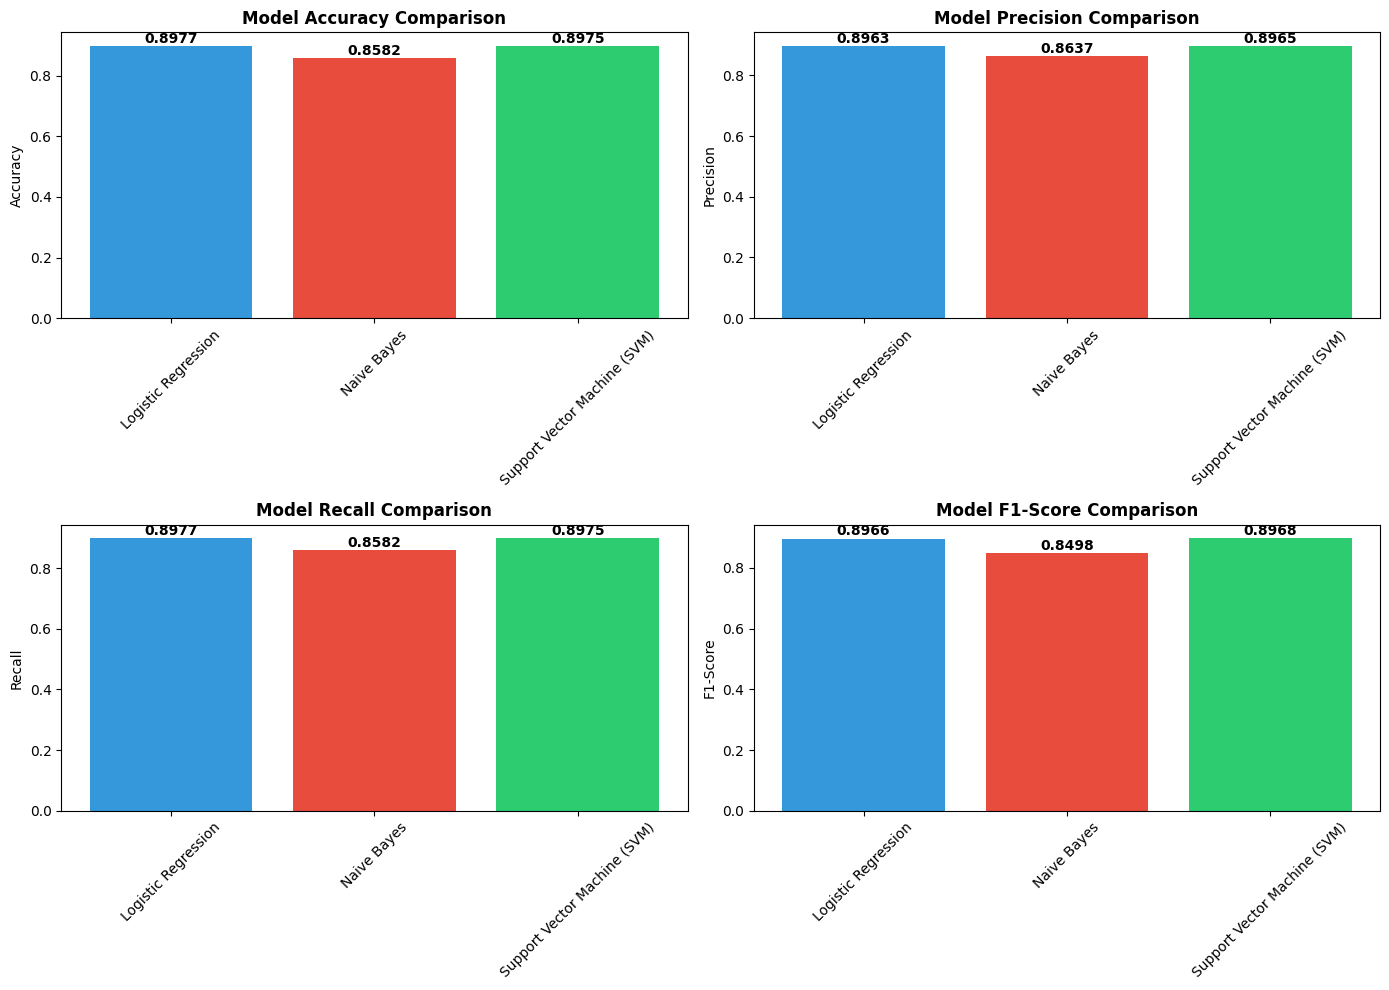

In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy comparison
axes[0, 0].bar(comparison_df['Model'], comparison_df['Accuracy'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['Accuracy']):
    axes[0, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# Precision comparison
axes[0, 1].bar(comparison_df['Model'], comparison_df['Precision'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0, 1].set_title('Model Precision Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['Precision']):
    axes[0, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# Recall comparison
axes[1, 0].bar(comparison_df['Model'], comparison_df['Recall'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1, 0].set_title('Model Recall Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['Recall']):
    axes[1, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# F1-Score comparison
axes[1, 1].bar(comparison_df['Model'], comparison_df['F1-Score'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1, 1].set_title('Model F1-Score Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['F1-Score']):
    axes[1, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Test with Sample Predictions

In [ ]:
def predict_emotion(text, model, vectorizer, stemmer, stop_words):
    """
    Predict emotion/sentiment for a given text using the best trained model
    """
    # Preprocess the input text
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    cleaned_text = ' '.join(tokens)

    # Vectorize the text
    text_vector = vectorizer.transform([cleaned_text])

    # Predict
    prediction = model.predict(text_vector)[0]

    return prediction, cleaned_text

# Test samples
test_samples = [
    "I am so happy and excited today!",
    "I feel really sad and depressed",
    "This makes me so angry and frustrated",
    "I am scared and frightened",
    "This is a neutral statement",
    "I absolutely love this, it's amazing!",
    "I hate this, it's terrible!"
]

print("\n" + "="*80)
print("EMOTION DETECTION PREDICTIONS USING THE BEST MODEL")
print("="*80)
print(f"Using: {best_model_name}\n")

for sample in test_samples:
    prediction, cleaned = predict_emotion(sample, best_model, vectorizer, stemmer, stop_words)
    print(f"Text:      {sample}")
    print(f"Cleaned:   {cleaned}")
    print(f"Emotion:   {prediction.upper()}")
    print("-" * 80)


EMOTION DETECTION PREDICTIONS USING THE BEST MODEL
Using: Logistic Regression

Text:      I am so happy and excited today!
Cleaned:   happi excit today
Emotion:   JOY
--------------------------------------------------------------------------------
Text:      I feel really sad and depressed
Cleaned:   feel realli sad depress
Emotion:   SAD
--------------------------------------------------------------------------------
Text:      This makes me so angry and frustrated
Cleaned:   make angri frustrat
Emotion:   ANGER
--------------------------------------------------------------------------------
Text:      I am scared and frightened
Cleaned:   scare frighten
Emotion:   FEAR
--------------------------------------------------------------------------------
Text:      This is a neutral statement
Cleaned:   neutral statement
Emotion:   JOY
--------------------------------------------------------------------------------
Text:      I absolutely love this, it's amazing!
Cleaned:   absolut love a

## 10. Save the Best Model

In [17]:
# Save the best model and vectorizer
import os

# Create a models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Generate model file names with the best model name
model_name = best_model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
model_path = f'/content/drive/MyDrive/BTECH SEM 8/AIML-HONORS/emotion_detection_best_model_{model_name}.pkl'
vectorizer_path = f'/content/drive/MyDrive/BTECH SEM 8/AIML-HONORS/tfidf_vectorizer_{model_name}.pkl'

try:
    # Save the best model
    pickle.dump(best_model, open(model_path, 'wb'))
    print(f"✓ Best Model Saved: {model_path}")

    # Save the vectorizer
    pickle.dump(vectorizer, open(vectorizer_path, 'wb'))
    print(f"✓ Vectorizer Saved: {vectorizer_path}")

    print("\n" + "="*70)
    print("MODEL DEPLOYMENT INFORMATION")
    print("="*70)
    print(f"Saved Model:        {model_name}")
    print(f"Model Accuracy:     {best_accuracy:.4f}")
    print(f"Model File:         {model_path}")
    print(f"Vectorizer File:    {vectorizer_path}")
    print("="*70)
    print("\nTo load and use the model in the future:")
    print(f"model = pickle.load(open('{model_path}', 'rb'))")
    print(f"vectorizer = pickle.load(open('{vectorizer_path}', 'rb'))")
    print("="*70)

except Exception as e:
    print(f"Error saving model: {e}")

✓ Best Model Saved: /content/drive/MyDrive/BTECH SEM 8/AIML-HONORS/emotion_detection_best_model_logistic_regression.pkl
✓ Vectorizer Saved: /content/drive/MyDrive/BTECH SEM 8/AIML-HONORS/tfidf_vectorizer_logistic_regression.pkl

MODEL DEPLOYMENT INFORMATION
Saved Model:        logistic_regression
Model Accuracy:     0.8977
Model File:         /content/drive/MyDrive/BTECH SEM 8/AIML-HONORS/emotion_detection_best_model_logistic_regression.pkl
Vectorizer File:    /content/drive/MyDrive/BTECH SEM 8/AIML-HONORS/tfidf_vectorizer_logistic_regression.pkl

To load and use the model in the future:
model = pickle.load(open('/content/drive/MyDrive/BTECH SEM 8/AIML-HONORS/emotion_detection_best_model_logistic_regression.pkl', 'rb'))
vectorizer = pickle.load(open('/content/drive/MyDrive/BTECH SEM 8/AIML-HONORS/tfidf_vectorizer_logistic_regression.pkl', 'rb'))


## Summary

This notebook successfully demonstrates a complete machine learning pipeline for emotion detection and sentiment analysis:

1. **Data Loading & Exploration**: Loaded and analyzed the emotion dataset
2. **Text Preprocessing**: Cleaned text by removing special characters, stopwords, and applying stemming
3. **Feature Extraction**: Converted text to numerical features using TF-IDF Vectorization
4. **Model Training**: Trained three different ML models:
   - Logistic Regression
   - Multinomial Naive Bayes
   - Support Vector Machine (SVM)
5. **Model Comparison**: Compared all models based on accuracy, precision, recall, and F1-score
6. **Best Model Selection**: Automatically selected the model with the highest accuracy
7. **Predictions**: Made predictions on sample texts using the best model
8. **Model Persistence**: Saved the best model and vectorizer for future use

The workflow can be adapted for different datasets or emotion classes by simply changing the CSV file path and adjusting the preprocessing parameters as needed.